# Whole-pipeline threshold evaluation (per-stage)

This notebook evaluates the **entire prediction cascade** (`Pipeline.run` in
`phishing_engine/core/pipeline.py`) end-to-end and characterizes how its decision
thresholds trade detection quality against latency.

stages run in order `url -> content -> domain`; a stage with `P(phish) >= its threshold`
**early-exits** with that stage's own model verdict; otherwise the URL escalates, and if no
stage exits the cascade **aggregates** every stage's probability (`mean`/`max`/`median` per
`decision.fallback_aggregation`) against the fixed `FALLBACK_DECISION_BOUNDARY` (0.5).

**Per-stage thresholds.** Each stage's early-exit bar is its own `StageConfig.threshold`,
falling back to the pipeline-wide `decision.threshold`. This notebook (1) sweeps a single
**shared** threshold as the baseline, (2) evaluates the **shipped per-stage config**, and
(3) **searches** for a better per-stage combination -- all on the held-out TEST split.

**Method.**
1. Extract all three stages' features for every labeled URL using the engine's own
   extractors (train/predict parity), keyed per-URL.
2. **Domain-grouped split** keyed on **registered domain (eTLD+1)** so no host crosses
   splits -- host-shared `domain` features can no longer leak train->test.
3. **80/20 train / test.** For each stage, train the model zoo on **train** and keep the best
   by `SELECTION_METRIC` on **test** (no separate validation split).
4. Score per-URL stage probabilities and **replay the real cascade** by reusing
   `Pipeline._build_result` (so the verdict can't drift from production), now honoring
   per-stage thresholds exactly like runtime.
5. Baseline shared-threshold sweep, then the shipped per-stage config, then a per-stage
   sensitivity analysis + (url x content) grid search.
6. Show the **latency vs F1 trade-off**, placing the per-stage operating points in that space.

**Prerequisites:** MongoDB running with collected, labeled data; run with the project's
`.venv` kernel; working directory = repo root (where `config/pipeline.json` lives).


In [1]:
import os, sys, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import tldextract                       # registered-domain (eTLD+1) grouping for the split

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import get_stage
from phishing_engine.core.pipeline import Pipeline, PipelineContext, FALLBACK_DECISION_BOUNDARY
from phishing_engine.storage.mongo import MongoStore

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# Model zoo (mirrors model_evaluation.ipynb). sklearn's Pipeline is aliased to SkPipeline
# so it does not shadow phishing_engine's cascade Pipeline imported above.
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok; FALLBACK_DECISION_BOUNDARY =", FALLBACK_DECISION_BOUNDARY)

imports ok; FALLBACK_DECISION_BOUNDARY = 0.5


## Parameters

In [2]:
CONFIG_PATH = "config/pipeline.json"
# Cap on labeled docs (0 = all). Override with PHISH_EVAL_LIMIT for a quick smoke run.
LIMIT       = int(os.environ.get("PHISH_EVAL_LIMIT", "0"))
RS          = 42          # shared random_state for the split + every model

# Per-stage model selection: train the zoo on TRAIN, keep the best by SELECTION_METRIC on TEST.
# (No separate validation split -- selecting the best-of-N on the test set gives the reported
# metrics a mild optimistic bias, accepted here for simplicity.) INCLUDE_SLOW_MODELS adds SVM.
SELECTION_METRIC    = "f1"   # column the per-stage zoo is ranked by (on test)
INCLUDE_SLOW_MODELS = False

# Domain-GROUPED split keyed on registered domain (eTLD+1): no domain crosses splits, so
# host-shared domain features can't leak train->test. 80/20 train/test via
# StratifiedGroupKFold(n_splits=5): 1 fold test / 4 folds train.
TRAIN_FRAC, TEST_FRAC = 0.8, 0.2

# Grid swept over the cascade's early-exit threshold. We report the whole curve; no single
# threshold is prescribed (see the sweep + latency sections).
THRESHOLDS = np.round(np.linspace(0.0, 1.0, 101), 4)

# Joint per-URL feature cache (extraction over thousands of docs is the slow part).
FEATURE_CACHE_DIR = "feature_cache"
USE_FEATURE_CACHE = True
FORCE_RECALC      = False
print(f"LIMIT={LIMIT}  selection_metric={SELECTION_METRIC}  include_slow={INCLUDE_SLOW_MODELS}")
print(f"split(grouped, eTLD+1)={TRAIN_FRAC}/{TEST_FRAC}")

LIMIT=0  selection_metric=f1  include_slow=False
split(grouped, eTLD+1)=0.8/0.2


## Connect to MongoDB and read the decision policy

The threshold/labels/aggregation come straight from the config's `pipeline.decision`
block, so the sweep is measured against the exact policy the engine ships with.

In [3]:
config   = load_config(CONFIG_PATH)
mongo    = config.pipeline.mongo
DECISION = config.pipeline.decision
STAGE_CONFIGS = {s.id: s for s in config.pipeline.stages}
POSITIVE = DECISION.positive_label   # "phish"
NEGATIVE = DECISION.negative_label   # "benign"
CURRENT_THRESHOLD = DECISION.threshold

# Production per-stage early-exit map: each stage's StageConfig.threshold, falling back to
# the pipeline-wide decision.threshold. "_default" is the fallback used by the replay.
CONFIG_THR = {s.id: (s.threshold if s.threshold is not None else DECISION.threshold)
              for s in config.pipeline.stages}
CONFIG_THR["_default"] = DECISION.threshold

store = MongoStore(mongo.uri, mongo.database, mongo.collection, mongo.domain_collection)
print(f"db={mongo.database!r} urls={mongo.collection!r} domains={mongo.domain_collection!r}")
print(f"decision: threshold(default)={DECISION.threshold} positive={POSITIVE!r} "
      f"negative={NEGATIVE!r} fallback_aggregation={DECISION.fallback_aggregation!r}")
print("per-stage early-exit thresholds:",
      {k: v for k, v in CONFIG_THR.items() if k != "_default"})
print("labeled docs with a domain record:", store.count_labeled(require="domain_record", limit=LIMIT))


db='phishing_engine' urls='url_documents' domains='domain_records'
decision: threshold(default)=0.99 positive='phish' negative='benign' fallback_aggregation='mean'
per-stage early-exit thresholds: {'url': 0.9, 'content': 0.8, 'domain': 0.99}


labeled docs with a domain record: 10625


## Joint per-URL feature extraction

One pass over `iter_labeled(require="domain_record")` (which `$lookup`-joins the domain
record and still carries `raw.content` when present). For each URL we run the **same**
extractors the training/prediction pipelines use and key everything by URL `_id`:

- **url** features from the URL string (always available),
- **domain** features from `raw.domain_record` (identical for every URL of a host),
- **content** features from `raw.content` when the page was collected.

`domain_ok` / `content_ok` record whether a stage produced features; a stage with no
features contributes no probability later (mirroring the cascade's "escalate" path). The
aligned matrices are cached to `feature_cache/` so re-runs skip the slow extraction.

In [4]:
URL_COLS     = STAGE_CONFIGS["url"].feature_columns
CONTENT_COLS = STAGE_CONFIGS["content"].feature_columns   # domain stage has no fixed columns

def _align(df, cols):
    '''Coerce to numeric (bools->0/1); if cols given, add missing + order to them, drop extras.

    Mirrors the coercion in core/training.py so the offline features match training exactly.
    '''
    df = df.replace({True: 1, False: 0})
    if cols:
        for c in cols:
            if c not in df.columns:
                df[c] = 0
        df = df[cols]
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _cache_paths(limit):
    suf = f"_lim{limit}" if limit else ""
    base = os.path.join(FEATURE_CACHE_DIR, f"pipeline_joint{suf}")
    return {k: f"{base}_{k}.csv" for k in ("meta", "url", "domain", "content")}

def build_joint_dataset(limit=LIMIT):
    paths = _cache_paths(limit)
    if USE_FEATURE_CACHE and not FORCE_RECALC and all(os.path.exists(p) for p in paths.values()):
        meta = pd.read_csv(paths["meta"])
        url_df, dom_df, con_df = (pd.read_csv(paths[k]) for k in ("url", "domain", "content"))
        print(f"[cache] loaded joint dataset: {len(meta)} URLs  ({FEATURE_CACHE_DIR}/)")
        return meta, url_df, dom_df, con_df

    url_stage = get_stage("url")(STAGE_CONFIGS["url"], None)
    dom_stage = get_stage("domain")(STAGE_CONFIGS["domain"], None)
    con_stage = get_stage("content")(STAGE_CONFIGS["content"], None)

    ids, refs, labels, has_content, dom_ok, con_ok = [], [], [], [], [], []
    url_rows, dom_rows, con_rows = [], [], []
    failed = 0
    t0 = time.perf_counter()
    total = store.count_labeled(require="domain_record", limit=limit)
    it = tqdm(store.iter_labeled(require="domain_record", limit=limit),
              total=total, desc="extracting features", unit="doc")
    for doc in it:
        label = doc.get("label")
        if label not in ("phish", "benign"):
            continue
        ctx = PipelineContext(url=doc.get("url", ""), normalized_url=doc["_id"],
                              domain=doc.get("domain", ""), label=label)
        raw = doc.get("raw") or {}
        try:
            u = url_stage.extract_features(ctx, {})
        except Exception:
            failed += 1
            continue
        try:
            d = dom_stage.extract_features(ctx, dom_stage.build_train_artifacts(doc))
        except Exception:
            d = {}
        if raw.get("content") is not None:
            try:
                c = con_stage.extract_features(ctx, con_stage.build_train_artifacts(doc))
            except Exception:
                c = {}
            hc = True
        else:
            c, hc = {}, False

        ids.append(doc["_id"]); refs.append(raw.get("domain_record_ref")); labels.append(label)
        has_content.append(hc); dom_ok.append(bool(d)); con_ok.append(hc and bool(c))
        url_rows.append(u); dom_rows.append(d); con_rows.append(c)

    print(f"extracted {len(ids)} URLs in {time.perf_counter() - t0:.0f}s "
          f"({failed} url-extraction failures skipped)")

    meta = pd.DataFrame({"_id": ids, "domain_ref": refs, "_label": labels,
                         "has_content": has_content, "domain_ok": dom_ok, "content_ok": con_ok})
    url_df = _align(pd.DataFrame(url_rows), URL_COLS)
    dom_df = _align(pd.DataFrame(dom_rows), None)          # keep extractor-produced columns
    con_df = _align(pd.DataFrame(con_rows), CONTENT_COLS)

    if USE_FEATURE_CACHE:
        os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
        meta.to_csv(paths["meta"], index=False)
        url_df.to_csv(paths["url"], index=False)
        dom_df.to_csv(paths["domain"], index=False)
        con_df.to_csv(paths["content"], index=False)
        print(f"[cache] saved joint dataset -> {FEATURE_CACHE_DIR}/")
    return meta, url_df, dom_df, con_df

meta, url_df, dom_df, con_df = build_joint_dataset()

# Positional alignment across every frame (index == row position).
meta   = meta.reset_index(drop=True)
url_df = url_df.reset_index(drop=True)
dom_df = dom_df.reset_index(drop=True)
con_df = con_df.reset_index(drop=True)
y = (meta["_label"].to_numpy() == POSITIVE).astype(int)

print("shapes:", {"meta": meta.shape, "url": url_df.shape,
                  "domain": dom_df.shape, "content": con_df.shape})
print(f"phish={int(y.sum())} benign={int((y == 0).sum())} | "
      f"with content={int(meta['has_content'].sum())} | "
      f"domain_ok={int(meta['domain_ok'].sum())} content_ok={int(meta['content_ok'].sum())}")

[cache] loaded joint dataset: 10306 URLs  (feature_cache/)
shapes: {'meta': (10306, 6), 'url': (10306, 39), 'domain': (10306, 136), 'content': (10306, 111)}
phish=4823 benign=5483 | with content=9618 | domain_ok=10306 content_ok=9618


## Domain-grouped train / test split

The split is keyed on the **registered domain (eTLD+1)** so **no domain crosses splits** --
host-shared `domain` features (identical for every URL of a host) therefore can't leak from
train into test, which a per-URL random split allowed (it put ~46% of test URLs on a
train-seen domain). **80/20** via `StratifiedGroupKFold(5)` (4 folds train / 1 fold test); a
leakage guard asserts the two domain sets are disjoint. Each stage's best model is picked on
the test split (no separate validation set).

In [5]:
# group key = registered domain (eTLD+1); offline (bundled suffix snapshot, no network).
_tld = tldextract.TLDExtract(suffix_list_urls=())

def _registered_domain(domain_ref, _id):
    host = domain_ref.split("|", 1)[0] if isinstance(domain_ref, str) and domain_ref else ""
    if not host:
        return str(_id)                       # fall back to the URL id if no host
    return _tld(host).registered_domain or host

groups = np.array([_registered_domain(r, i)
                   for r, i in zip(meta["domain_ref"], meta["_id"])])
print(f"registered-domain groups: {len(set(groups))}  (from {meta['_id'].nunique()} URLs)")

# grouped, stratified 80/20 split via 5 folds -> 1 test / 4 train.
sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RS)
folds = [te for _, te in sgkf.split(np.arange(len(meta)), y, groups)]
test_idx  = folds[0]
train_idx = np.concatenate(folds[1:])

for name, idx in [("train", train_idx), ("test", test_idx)]:
    yy = y[idx]
    assert set(np.unique(yy)) == {0, 1}, f"{name} split is single-class; adjust seed/LIMIT"
    print(f"{name:5}: {len(idx):5} URLs  ({len(set(groups[idx])):4} domains)  "
          f"phish={int(yy.sum())} benign={int((yy == 0).sum())}")

# leakage guard: registered domains must be disjoint across train/test.
_g = {n: set(groups[i]) for n, i in [("tr", train_idx), ("te", test_idx)]}
assert not (_g["tr"] & _g["te"]), "domain leak across splits!"
print("leakage guard: 0 shared domains across train/test  OK")

registered-domain groups: 4258  (from 10306 URLs)


train:  8188 URLs  (3757 domains)  phish=3801 benign=4387
test :  2118 URLs  ( 501 domains)  phish=1022 benign=1096
leakage guard: 0 shared domains across train/test  OK


## Per-stage model selection (train a zoo, keep the best on TEST)

Each stage trains every algorithm (Logistic Regression, Decision Tree, Random Forest, Extra
Trees, Gradient Boosting, KNN, XGBoost, LightGBM; SVM optional) on the **train** split and
keeps the **best by `SELECTION_METRIC` on the TEST split** to drive the cascade. Each stage is
fit on the unit it predicts on:

- **url** / **content**: one row per URL (content only on URLs whose page was collected).
- **domain**: deduplicated to one row per `domain_ref`, labeled `phish` if *any* URL of
  that domain is phish (matching `collect_training_data` in `core/training.py`).

Labels are encoded `1=phish / 0=benign`; `phish_proba` reads the phish column back via
`model.classes_`. (With no separate validation split, selection and reporting share the test
set, so the headline numbers carry a mild optimistic bias.)

In [6]:
def make_models():
    '''Candidate models per stage -- same zoo as model_evaluation.ipynb.'''
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    models = {
        "Logistic Regression": SkPipeline([("scaler", StandardScaler()),
                                           ("clf", LogisticRegression(max_iter=1000, random_state=RS))]),
        "Decision Tree":     DecisionTreeClassifier(random_state=RS),
        "Random Forest":     RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Extra Trees":       ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RS),
        "KNN":               SkPipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "XGBoost":           XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                           subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                                           tree_method="hist", n_jobs=-1, random_state=RS),
        "LightGBM":          LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1,
                                            random_state=RS, verbose=-1),
    }
    if INCLUDE_SLOW_MODELS:
        models["SVM (RBF)"] = SkPipeline([("scaler", StandardScaler()),
                                          ("clf", SVC(kernel="rbf", probability=True, random_state=RS))])
    return models

def phish_proba(model, X):
    '''P(phish) column, located via model.classes_ (labels are 1=phish / 0=benign).'''
    idx = list(model.classes_).index(1)
    return model.predict_proba(X)[:, idx]

def _dedup_domain(idx):
    '''Rows + labels for one row per domain_ref (features identical within a host;
    phish if any URL of the ref is phish) -- matches collect_training_data.'''
    rows, labels = [], []
    for ref, sub in meta.iloc[idx].groupby("domain_ref"):
        ok = sub.index[sub["domain_ok"].to_numpy()]
        if len(ok) == 0:
            continue                                   # this domain produced no features
        rows.append(int(ok[0]))                        # features identical within a domain
        labels.append(1 if (sub["_label"] == POSITIVE).any() else 0)
    return rows, np.array(labels)

def stage_matrices(stage):
    '''(X_train, y_train, X_test, y_test) for one stage, on its prediction unit.'''
    if stage == "url":
        return url_df.iloc[train_idx], y[train_idx], url_df.iloc[test_idx], y[test_idx]
    if stage == "content":
        sel = lambda I: [int(i) for i in I if meta.at[int(i), "content_ok"]]
        tr, te = sel(train_idx), sel(test_idx)
        return con_df.loc[tr], y[tr], con_df.loc[te], y[te]
    if stage == "domain":
        tr, ytr = _dedup_domain(train_idx)
        te, yte = _dedup_domain(test_idx)
        return dom_df.loc[tr], ytr, dom_df.loc[te], yte
    raise ValueError(stage)

def _score(y_true, proba):
    '''Threshold-independent (PR-AUC, ROC-AUC) + 0.5-boundary metrics for one model.'''
    preds = (proba >= 0.5).astype(int)
    multi = len(np.unique(y_true)) > 1
    return {"pr_auc":    average_precision_score(y_true, proba) if multi else float("nan"),
            "roc_auc":   roc_auc_score(y_true, proba) if multi else float("nan"),
            "f1":        f1_score(y_true, preds, zero_division=0),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall":    recall_score(y_true, preds, zero_division=0),
            "accuracy":  accuracy_score(y_true, preds)}

def select_best(stage):
    '''Fit every zoo model on train; rank by SELECTION_METRIC on the TEST split.'''
    Xtr, ytr, Xte, yte = stage_matrices(stage)
    assert set(np.unique(ytr)) == {0, 1}, f"{stage} train split single-class; adjust seed/LIMIT"
    rows, fitted = [], {}
    for name, model in make_models().items():
        t0 = time.perf_counter()
        try:
            model.fit(Xtr, ytr)
        except Exception as e:
            print(f"  [skip] {stage}/{name}: {e}")
            continue
        rows.append({"model": name, **_score(yte, phish_proba(model, Xte)),
                     "fit_sec": time.perf_counter() - t0})
        fitted[name] = model
    table = pd.DataFrame(rows).sort_values(SELECTION_METRIC, ascending=False).reset_index(drop=True)
    best_name = table.iloc[0]["model"]
    counts = (len(ytr), int(np.asarray(ytr).sum()), len(yte), int(np.asarray(yte).sum()))
    return table, fitted, best_name, counts

STAGES = ["url", "domain", "content"]
stage_tables, fitted_models, selected, stage_counts = {}, {}, {}, {}
for stage in STAGES:
    table, fitted, best_name, counts = select_best(stage)
    stage_tables[stage]  = table
    fitted_models[stage] = fitted
    selected[stage]      = best_name
    stage_counts[stage]  = counts
    top = table.iloc[0]
    print(f"{stage:8} best by {SELECTION_METRIC}: {best_name:20} "
          f"(TEST PR-AUC={top['pr_auc']:.4f} ROC-AUC={top['roc_auc']:.4f} F1@.5={top['f1']:.4f})  "
          f"train={counts[0]}(phish={counts[1]}) / test={counts[2]}(phish={counts[3]})")

# the cascade uses each stage's winning model
url_model = fitted_models["url"][selected["url"]]
dom_model = fitted_models["domain"][selected["domain"]]
con_model = fitted_models["content"][selected["content"]]
MODEL_DESC = " | ".join(f"{s}:{selected[s]}" for s in STAGES)
print("\nselected models ->", MODEL_DESC)

url      best by f1: LightGBM             (TEST PR-AUC=0.9998 ROC-AUC=0.9997 F1@.5=0.9793)  train=8188(phish=3801) / test=2118(phish=1022)


domain   best by f1: XGBoost              (TEST PR-AUC=0.9987 ROC-AUC=0.9986 F1@.5=0.9893)  train=5039(phish=2990) / test=1368(phish=835)


content  best by f1: Extra Trees          (TEST PR-AUC=0.9784 ROC-AUC=0.9876 F1@.5=0.9661)  train=7544(phish=3294) / test=2074(phish=1022)

selected models -> url:LightGBM | domain:XGBoost | content:Extra Trees


## Per-stage model comparison & selected best (on the TEST split)

The full ranking of every candidate per stage (sorted by the selection metric), then the
best-per-stage summary and a side-by-side bar chart of the chosen models' headline metrics.
All numbers here are on the **test** split. PR-AUC / ROC-AUC are threshold-independent;
precision/recall/F1 are at each model's natural 0.5 boundary.


===== url  (best by f1: LightGBM) =====
              model  pr_auc  roc_auc     f1  precision  recall  accuracy  fit_sec
           LightGBM  0.9998   0.9997 0.9793     0.9622  0.9971    0.9797   2.4960
        Extra Trees  0.9778   0.9952 0.9789     0.9587  1.0000    0.9792   1.3949
            XGBoost  0.9997   0.9997 0.9784     0.9587  0.9990    0.9788   0.9761
      Random Forest  0.9862   0.9959 0.9779     0.9586  0.9980    0.9783   1.6795
                KNN  0.9874   0.9940 0.9729     0.9472  1.0000    0.9731   0.1877
  Gradient Boosting  0.9996   0.9996 0.9714     0.9470  0.9971    0.9717   1.2228
Logistic Regression  0.9988   0.9989 0.9682     0.9393  0.9990    0.9684   0.1247
      Decision Tree  0.9420   0.9702 0.9663     0.9391  0.9951    0.9665   0.0611

===== domain  (best by f1: XGBoost) =====
              model  pr_auc  roc_auc     f1  precision  recall  accuracy  fit_sec
            XGBoost  0.9987   0.9986 0.9893     0.9789  1.0000    0.9868   2.1200
      Random F

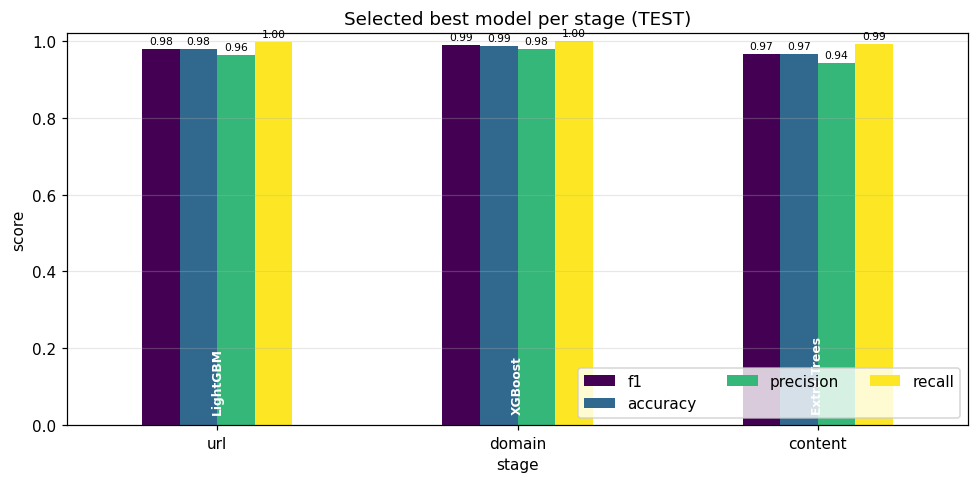

,best_model,pr_auc,roc_auc,precision,recall,f1,accuracy
stage,,,,,,,
url,LightGBM,0.9998,0.9997,0.9622,0.9971,0.9793,0.9797
domain,XGBoost,0.9987,0.9986,0.9789,1.0000,0.9893,0.9868
content,Extra Trees,0.9784,0.9876,0.9423,0.9912,0.9661,0.9658


In [7]:
REPORT_COLS = ["pr_auc", "roc_auc", "precision", "recall", "f1", "accuracy"]

# full per-stage comparison tables (every candidate, sorted by the selection metric)
for stage in STAGES:
    print(f"\n===== {stage}  (best by {SELECTION_METRIC}: {selected[stage]}) =====")
    print(stage_tables[stage].round(4).to_string(index=False))

# best-per-stage summary (the models the cascade will use)
per_stage = pd.DataFrame([
    {"stage": s, "best_model": selected[s],
     **stage_tables[s].set_index("model").loc[selected[s], REPORT_COLS].to_dict()}
    for s in STAGES
]).set_index("stage")
print("\nBest model per stage (TEST split):")
print(per_stage.round(4).to_string())

# bar chart of the selected winners' headline metrics (without F1)
ax = per_stage[["f1", "accuracy", "precision", "recall"]].plot(
    kind="bar", figsize=(9, 4.5), ylim=(0, 1.02), rot=0, colormap="viridis")
ax.set_title("Selected best model per stage (TEST)")
ax.set_xlabel("stage"); ax.set_ylabel("score"); ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", ncol=3)
for i, s in enumerate(STAGES):          # annotate each group with the winning model name
    ax.annotate(selected[s], (i, 0.03), ha="center", va="bottom", rotation=90,
                fontsize=8, color="white", fontweight="bold")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", padding=2, fontsize=7)
plt.tight_layout(); plt.show()
per_stage.round(4)

## Score per-URL stage probabilities and assemble the cascade inputs (test)

For each URL we build the ordered list `[("url", p), ("domain", p), ("content", p)]`,
**omitting** any stage that produced no features (`domain_ok` / `content_ok` False) -- the
cascade treats a stage with no usable probability as "escalate", so it must not appear. We
build these for the **test** split (used for the report and plots).

In [8]:
def stage_probs_for(idx):
    '''Per-URL ordered [(stage, P(phish)), ...] for the rows in `idx`.'''
    pu = phish_proba(url_model, url_df.iloc[idx])
    pd_ = phish_proba(dom_model, dom_df.iloc[idx])
    pc = phish_proba(con_model, con_df.iloc[idx])
    dok = meta["domain_ok"].to_numpy()[idx]
    cok = meta["content_ok"].to_numpy()[idx]
    out = []
    for k in range(len(idx)):
        lst = [("url", float(pu[k]))]
        if dok[k]:
            lst.append(("domain", float(pd_[k])))
        if cok[k]:
            lst.append(("content", float(pc[k])))
        out.append(lst)
    return out

test_probs = stage_probs_for(test_idx); y_test = y[test_idx]
print(f"assembled prob lists: test={len(test_probs)}")
print("example (test[0]):", test_probs[0])

assembled prob lists: test=2118
example (test[0]): [('url', 0.0001666011369251145), ('domain', 5.6813347327988595e-05)]


## Cascade replay (reuses the production decision logic)

`cascade()` rebuilds the `(stage, p)` list and `early_exit` exactly as the loop in
`Pipeline.run` does, then defers to `Pipeline._build_result` for the verdict -- the same
aggregation and the fixed `FALLBACK_DECISION_BOUNDARY`. So the offline verdict is identical
to production by construction; only the early-exit threshold is varied.

In [9]:
_replay = Pipeline(stages=[], decision=DECISION)
_ctx = PipelineContext(url="", normalized_url="", domain="")

# Production cascade order (so the replay's early-exit order matches Pipeline.run).
CASCADE_ORDER = [s.id for s in config.pipeline.stages if s.enabled]
_rank = {s: i for i, s in enumerate(CASCADE_ORDER)}

def _thr_for(thresholds, sid):
    '''Early-exit threshold for one stage. `thresholds` is either a scalar shared by every
    stage, or a {stage_id: thr} map (optional "_default") -- mirroring production, where
    StageConfig.threshold overrides decision.threshold per stage.'''
    if isinstance(thresholds, dict):
        v = thresholds.get(sid)
        return v if v is not None else thresholds.get("_default", DECISION.threshold)
    return thresholds

def cascade(prob_list, thresholds):
    '''Return (decision, stage_id, route) for one URL. `thresholds`: scalar (shared) or a
    per-stage map. Iterates in production cascade order; reuses Pipeline._build_result so
    verdicts match runtime.'''
    ordered = sorted(prob_list, key=lambda sp: _rank.get(sp[0], 99))
    collected, early_exit = [], None
    for sid, p in ordered:
        collected.append((sid, p))
        if p >= _thr_for(thresholds, sid):
            early_exit = (sid, p)
            break
    res = _replay._build_result(_ctx, collected, early_exit)
    if early_exit is not None:
        route = "early_exit"
    elif res.decision == "unknown":
        route = "unknown"
    else:
        route = "fallback"
    return res.decision, res.stage_id, route

# spot-check: shared threshold vs the production per-stage map on the highest-url-prob URL
print("cascade order:", CASCADE_ORDER)
_demo = max(test_probs, key=lambda L: L[0][1])
print("highest-url-prob demo:", _demo)
print("  shared t=0.5     ->", cascade(_demo, 0.5))
print("  per-stage CONFIG ->", cascade(_demo, CONFIG_THR))


cascade order: ['url', 'content', 'domain']
highest-url-prob demo: [('url', 0.9999825645538373), ('domain', 0.9998644590377808), ('content', 0.73)]
  shared t=0.5     -> ('phish', 'url', 'early_exit')
  per-stage CONFIG -> ('phish', 'url', 'early_exit')


## Shared-threshold sweep (baseline)

The sweep below applies **one shared threshold to every stage** (the original single-threshold
behavior) and serves as the baseline curve. The per-stage configuration is evaluated against
it in the following sections.


In [10]:
def evaluate(prob_lists, y_true, threshold):
    preds, routes = [], []
    for L in prob_lists:
        dec, _sid, route = cascade(L, threshold)
        preds.append(1 if dec == POSITIVE else 0)
        routes.append(route)
    preds = np.asarray(preds)
    npos, nben = int((y_true == 1).sum()), int((y_true == 0).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    return {
        "threshold":  threshold,
        "precision":  precision_score(y_true, preds, zero_division=0),
        "recall":     recall_score(y_true, preds, zero_division=0),
        "f1":         f1_score(y_true, preds, zero_division=0),
        "accuracy":   accuracy_score(y_true, preds),
        "fnr":        fn / npos if npos else 0.0,   # missed phish / all phish (= 1 - recall)
        "fpr":        fp / nben if nben else 0.0,   # flagged benign / all benign
        "pred_phish": int(preds.sum()),
        "n_unknown":  int(sum(r == "unknown" for r in routes)),
    }

sweep = pd.DataFrame([evaluate(test_probs, y_test, t) for t in THRESHOLDS])   # test (report/plots)

print("TEST sweep (every 10th threshold):")
print(sweep.iloc[::10][["threshold", "precision", "recall", "f1", "accuracy", "fnr", "fpr", "pred_phish"]]
      .round(4).to_string(index=False))
print(f"\nconfig (shipped) threshold = {CURRENT_THRESHOLD}  (shown for reference below)")

TEST sweep (every 10th threshold):
 threshold  precision  recall     f1  accuracy    fnr    fpr  pred_phish
       0.0     0.9622  0.9971 0.9793    0.9797 0.0029 0.0365        1059
       0.1     0.9051  0.9980 0.9493    0.9485 0.0020 0.0976        1127
       0.2     0.9011  0.9980 0.9471    0.9462 0.0020 0.1022        1132
       0.3     0.8995  0.9980 0.9462    0.9452 0.0020 0.1040        1134
       0.4     0.8987  0.9980 0.9458    0.9448 0.0020 0.1049        1135
       0.5     0.8981  1.0000 0.9463    0.9452 0.0000 0.1058        1138
       0.6     0.9150  1.0000 0.9556    0.9551 0.0000 0.0867        1117
       0.7     0.9282  1.0000 0.9628    0.9627 0.0000 0.0721        1101
       0.8     0.9642  1.0000 0.9817    0.9821 0.0000 0.0347        1060
       0.9     0.9789  1.0000 0.9894    0.9896 0.0000 0.0201        1044
       1.0     0.9951  0.9990 0.9971    0.9972 0.0010 0.0046        1026

config (shipped) threshold = 0.99  (shown for reference below)


## Metrics & error rates vs. threshold (TEST)

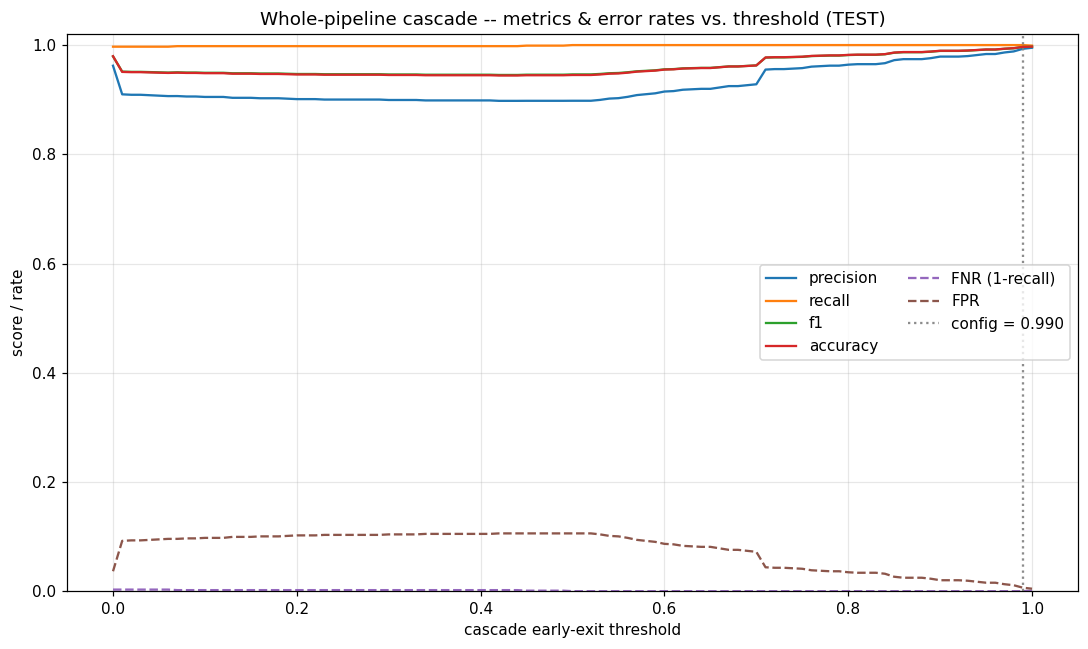

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(sweep["threshold"], sweep[m], label=m, color=c)
# error rates (lower is better) -- dashed so they read apart from the score curves
ax.plot(sweep["threshold"], sweep["fnr"], label="FNR (1-recall)", color="tab:purple", ls="--")
ax.plot(sweep["threshold"], sweep["fpr"], label="FPR", color="tab:brown", ls="--")
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9, label=f"config = {CURRENT_THRESHOLD:.3f}")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("score / rate")
ax.set_title("Whole-pipeline cascade -- metrics & error rates vs. threshold (TEST)")
ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend(loc="center right", ncol=2)
plt.tight_layout(); plt.show()

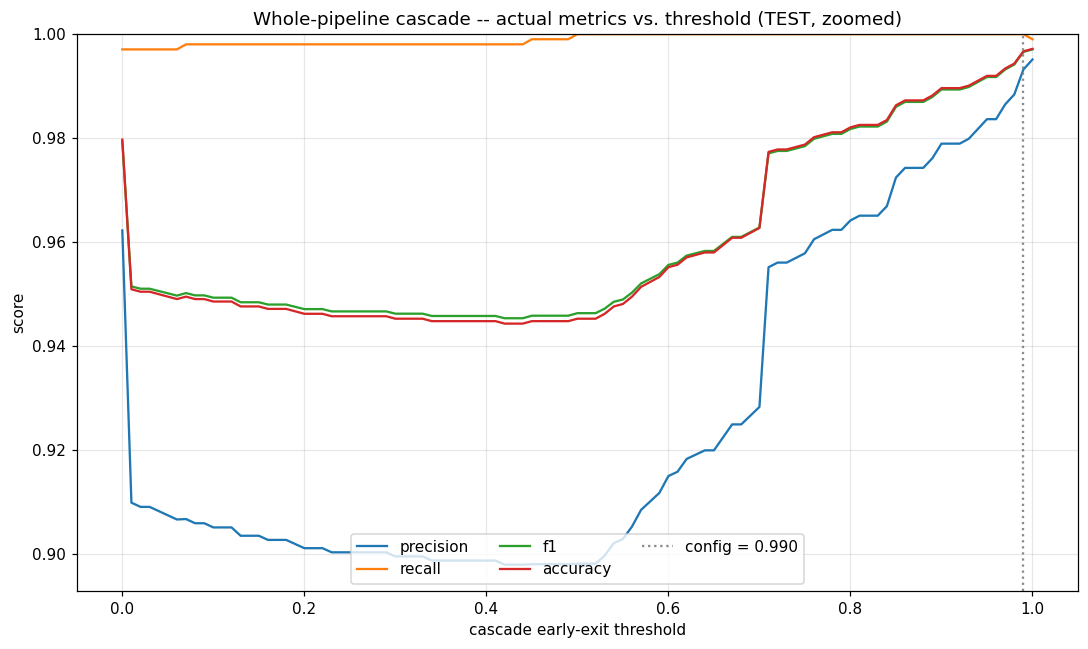

,min,max
precision,0.8979,0.9951
recall,0.9971,1.0000
f1,0.9453,0.9971
accuracy,0.9443,0.9972


In [12]:
# Zoomed view of the headline metrics across thresholds.
metrics = ["precision", "recall", "f1", "accuracy"]
metric_bounds = {m: {"min": float(np.nanmin(sweep[m])), "max": float(np.nanmax(sweep[m]))}
                 for m in metrics}

fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(sweep["threshold"], sweep[m], label=m, color=c)
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9, label=f"config = {CURRENT_THRESHOLD:.3f}")
ymin = min(v["min"] for v in metric_bounds.values())
ymax = max(v["max"] for v in metric_bounds.values())
ypad = 0.05 * (ymax - ymin) if not np.isclose(ymax - ymin, 0) else 0.05
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("score")
ax.set_title("Whole-pipeline cascade -- actual metrics vs. threshold (TEST, zoomed)")
ax.set_ylim(max(0.0, ymin - ypad), min(1.0, ymax + ypad)); ax.grid(alpha=0.3); ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

pd.DataFrame(metric_bounds).T.round(4)

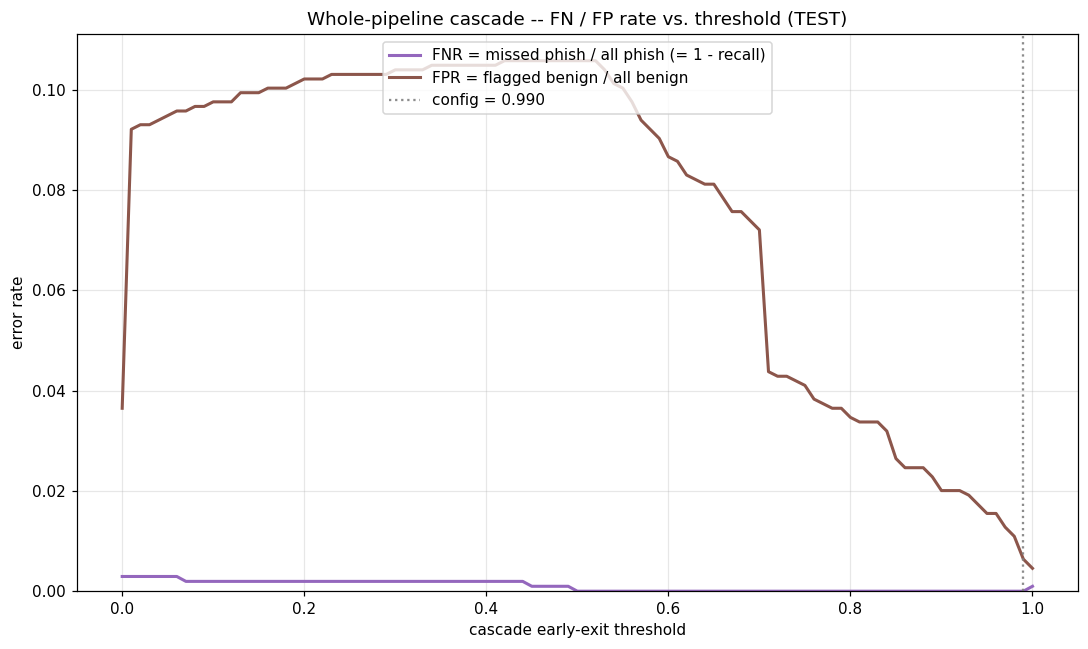

FN / FP rates at representative thresholds (TEST; config = 0.99):
              FNR     FPR  recall  precision
threshold                                   
0.00       0.0029  0.0365  0.9971     0.9622
0.50       0.0000  0.1058  1.0000     0.8981
0.99       0.0000  0.0064  1.0000     0.9932
1.00       0.0010  0.0046  0.9990     0.9951


,FNR,FPR,recall,precision
threshold,,,,
0.00,0.0029,0.0365,0.9971,0.9622
0.50,0.0000,0.1058,1.0000,0.8981
0.99,0.0000,0.0064,1.0000,0.9932
1.00,0.0010,0.0046,0.9990,0.9951


In [13]:
# Dedicated false-negative / false-positive rate analysis (their own scale, both are small).
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep["threshold"], sweep["fnr"], color="tab:purple", lw=2,
        label="FNR = missed phish / all phish (= 1 - recall)")
ax.plot(sweep["threshold"], sweep["fpr"], color="tab:brown", lw=2,
        label="FPR = flagged benign / all benign")
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9, label=f"config = {CURRENT_THRESHOLD:.3f}")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("error rate")
ax.set_ylim(bottom=0); ax.grid(alpha=0.3); ax.legend(loc="upper center")
ax.set_title("Whole-pipeline cascade -- FN / FP rate vs. threshold (TEST)")
plt.tight_layout(); plt.show()

# error rates at a few representative thresholds (incl. the shipped config)
def _erow(t):
    i = int((sweep["threshold"] - t).abs().idxmin())
    return sweep.iloc[i]
reps = sorted({0.0, 0.5, float(CURRENT_THRESHOLD), 0.99, 1.0})
err_tbl = pd.DataFrame([
    {"threshold": _erow(t)["threshold"], "FNR": _erow(t)["fnr"], "FPR": _erow(t)["fpr"],
     "recall": _erow(t)["recall"], "precision": _erow(t)["precision"]}
    for t in reps
]).set_index("threshold")
print(f"FN / FP rates at representative thresholds (TEST; config = {CURRENT_THRESHOLD}):")
print(err_tbl.round(4).to_string())
err_tbl.round(4)

## Shipped **per-stage** config on the held-out TEST split

Evaluates the cascade at the production per-stage thresholds `CONFIG_THR` (each stage uses its
own `StageConfig.threshold`, falling back to `decision.threshold`) and compares it to the best
single shared threshold from the sweep above.


In [14]:
def predict_at(prob_lists, thresholds):
    '''0/1 phish predictions at a shared scalar OR a per-stage threshold map.'''
    return np.asarray([1 if cascade(L, thresholds)[0] == POSITIVE else 0 for L in prob_lists])

def _metrics_row(preds):
    return {"precision": precision_score(y_test, preds, zero_division=0),
            "recall":    recall_score(y_test, preds, zero_division=0),
            "f1":        f1_score(y_test, preds, zero_division=0),
            "accuracy":  accuracy_score(y_test, preds),
            "pred_phish": int(preds.sum())}

# Shipped per-stage config (production behavior) on TEST.
preds_cfg = predict_at(test_probs, CONFIG_THR)
print("per-stage thresholds:", {k: v for k, v in CONFIG_THR.items() if k != "_default"})
print("=== TEST @ shipped per-stage config ===")
print(classification_report(y_test, preds_cfg, target_names=[NEGATIVE, POSITIVE], digits=4))

# Best single shared threshold (by F1) from the sweep, for comparison.
best_shared = sweep.loc[sweep["f1"].idxmax()]

summary = pd.DataFrame([
    {"which": f"best shared t={best_shared['threshold']:.2f}",
     "precision": best_shared["precision"], "recall": best_shared["recall"],
     "f1": best_shared["f1"], "accuracy": best_shared["accuracy"],
     "pred_phish": int(best_shared["pred_phish"])},
    {"which": "shipped per-stage", **_metrics_row(preds_cfg)},
]).set_index("which")
print("shipped per-stage config vs. best shared threshold (TEST):")
summary.round(4)


per-stage thresholds: {'url': 0.9, 'content': 0.8, 'domain': 0.99}
=== TEST @ shipped per-stage config ===
              precision    recall  f1-score   support

      benign     1.0000    0.9745    0.9871      1096
       phish     0.9733    1.0000    0.9865      1022

    accuracy                         0.9868      2118
   macro avg     0.9867    0.9872    0.9868      2118
weighted avg     0.9871    0.9868    0.9868      2118

shipped per-stage config vs. best shared threshold (TEST):


,precision,recall,f1,accuracy,pred_phish
which,,,,,
best shared t=1.00,0.9951,0.999,0.9971,0.9972,1026
shipped per-stage,0.9733,1.000,0.9865,0.9868,1050


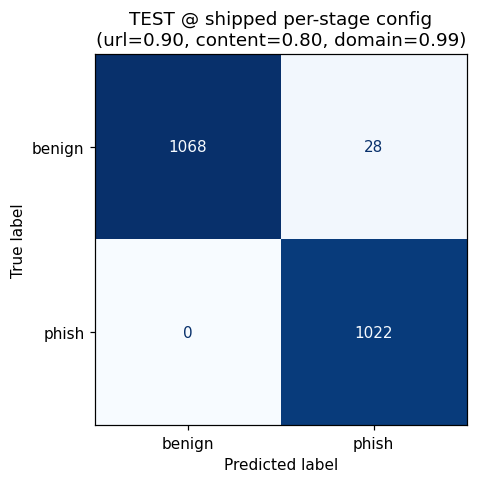

In [15]:
cm_cfg = confusion_matrix(y_test, preds_cfg)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm_cfg, display_labels=[NEGATIVE, POSITIVE]).plot(
    cmap="Blues", colorbar=False, ax=ax)
_thr_txt = ", ".join(f"{k}={v:.2f}" for k, v in CONFIG_THR.items() if k != "_default")
ax.set_title(f"TEST @ shipped per-stage config\n({_thr_txt})")
plt.tight_layout(); plt.show()


## Cascade decision funnel

How each test URL was decided at the **shipped config threshold**: which stage early-exited
it to `phish`, or whether it fell through to the aggregated mean fallback. The counts sum to
the number of evaluated URLs.

How the 2118 TEST URLs were decided at the shipped per-stage config:


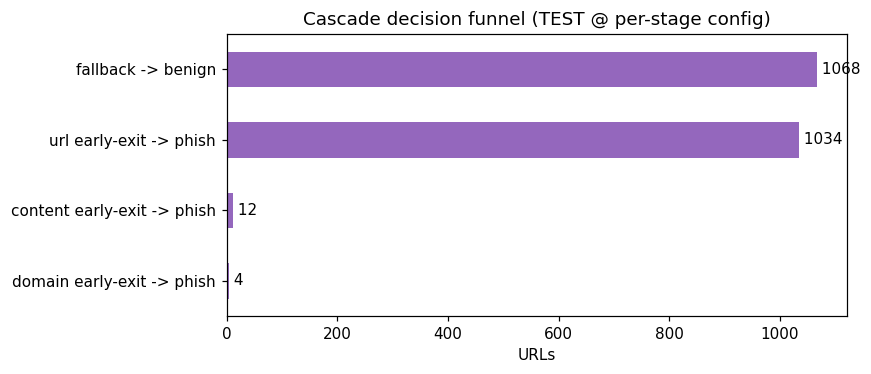

fallback -> benign             1068
url early-exit -> phish        1034
content early-exit -> phish      12
domain early-exit -> phish        4
dtype: int64

In [16]:
routes = Counter()
for L in test_probs:
    dec, sid, route = cascade(L, CONFIG_THR)
    if route == "early_exit":
        key = f"{sid} early-exit -> {dec}"
    elif route == "fallback":
        key = f"fallback -> {dec}"
    else:
        key = "unknown"
    routes[key] += 1

funnel = pd.Series(routes).sort_values(ascending=False)
assert funnel.sum() == len(test_probs)
print(f"How the {len(test_probs)} TEST URLs were decided at the shipped per-stage config:")
ax = funnel.iloc[::-1].plot(kind="barh", figsize=(8, 3.5), color="tab:purple")
ax.set_xlabel("URLs"); ax.set_title("Cascade decision funnel (TEST @ per-stage config)")
for i, v in enumerate(funnel.iloc[::-1].values):
    ax.text(v, i, f" {v}", va="center")
plt.tight_layout(); plt.show()
funnel


## Per-stage threshold search (the payoff of per-stage thresholds)

Two analyses on the TEST split:
1. **Coordinate sensitivity** -- vary one stage's threshold while holding the others at the
   shipped config, to see how much each transition's bar matters.
2. **Joint (url x content) grid search** -- find the per-stage combination that maximizes F1
   (domain held at its config value), and compare it to the best shared threshold and the
   shipped config.


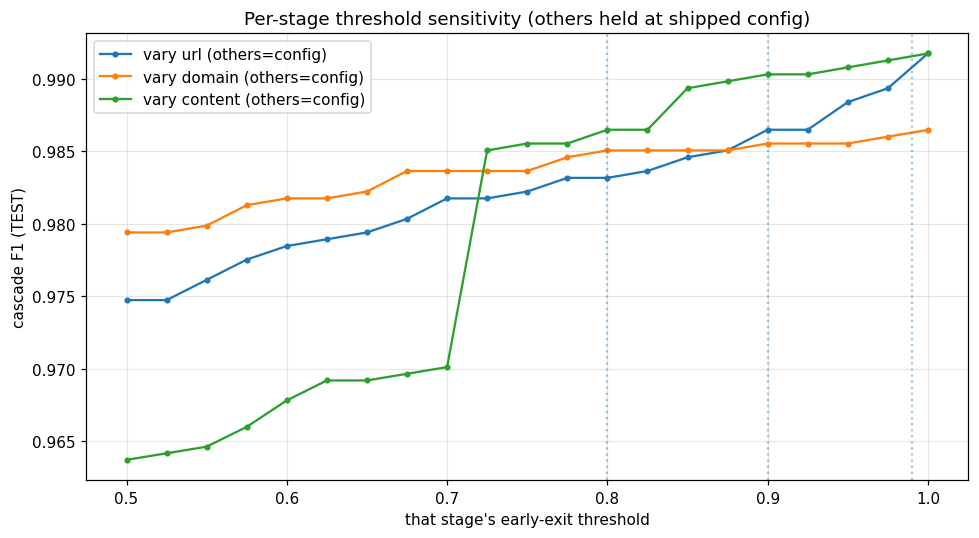

In [17]:
# 1) Coordinate sensitivity: vary one stage, hold the others at the shipped config.
GRID = np.round(np.linspace(0.50, 1.00, 21), 4)

def f1_at(thr_map):
    return f1_score(y_test, predict_at(test_probs, thr_map), zero_division=0)

coord = {}
for stage in STAGES:
    f1s = []
    for t in GRID:
        m = dict(CONFIG_THR); m[stage] = float(t)
        f1s.append(f1_at(m))
    coord[stage] = f1s

fig, ax = plt.subplots(figsize=(9, 5))
for stage in STAGES:
    ax.plot(GRID, coord[stage], marker="o", ms=3, label=f"vary {stage} (others=config)")
    ax.axvline(CONFIG_THR[stage], ls=":", alpha=0.4)
ax.set_xlabel("that stage's early-exit threshold")
ax.set_ylabel("cascade F1 (TEST)")
ax.set_title("Per-stage threshold sensitivity (others held at shipped config)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


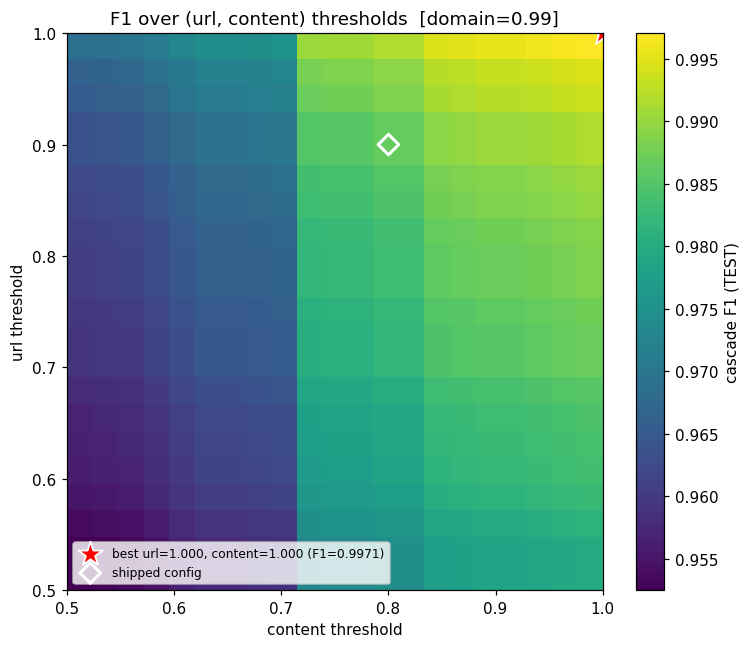

best per-stage: {'url': 1.0, 'content': 1.0, 'domain': 0.99} F1=0.9971

                    precision  recall      f1  accuracy
which                                                  
best shared t=1.00     0.9951   0.999  0.9971    0.9972
shipped per-stage      0.9733   1.000  0.9865    0.9868
searched per-stage     0.9942   1.000  0.9971    0.9972


In [18]:
# 2) Joint (url x content) grid search; domain held at its config value.
dom_thr = CONFIG_THR["domain"]
F1 = np.zeros((len(GRID), len(GRID)))
for iu, tu in enumerate(GRID):
    for ic, tc in enumerate(GRID):
        thr = {"url": float(tu), "content": float(tc), "domain": dom_thr,
               "_default": DECISION.threshold}
        F1[iu, ic] = f1_at(thr)

bi = np.unravel_index(int(np.argmax(F1)), F1.shape)
best_thr = {"url": float(GRID[bi[0]]), "content": float(GRID[bi[1]]), "domain": dom_thr,
            "_default": DECISION.threshold}
best_f1 = float(F1[bi])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(F1, origin="lower", aspect="auto", cmap="viridis",
               extent=[GRID[0], GRID[-1], GRID[0], GRID[-1]])
plt.colorbar(im, label="cascade F1 (TEST)")
ax.scatter([GRID[bi[1]]], [GRID[bi[0]]], marker="*", s=280, c="red", edgecolor="white",
           lw=1.2, label=f"best url={GRID[bi[0]]:.3f}, content={GRID[bi[1]]:.3f} (F1={best_f1:.4f})")
ax.scatter([CONFIG_THR["content"]], [CONFIG_THR["url"]], marker="D", s=90, facecolor="none",
           edgecolor="white", lw=2, label="shipped config")
ax.set_xlabel("content threshold"); ax.set_ylabel("url threshold")
ax.set_title(f"F1 over (url, content) thresholds  [domain={dom_thr:.2f}]")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

# Three-way comparison on TEST.
def _m(preds):
    r = _metrics_row(preds)
    return {k: r[k] for k in ("precision", "recall", "f1", "accuracy")}

cmp = pd.DataFrame([
    {"which": f"best shared t={best_shared['threshold']:.2f}",
     "precision": best_shared["precision"], "recall": best_shared["recall"],
     "f1": best_shared["f1"], "accuracy": best_shared["accuracy"]},
    {"which": "shipped per-stage", **_m(preds_cfg)},
    {"which": "searched per-stage", **_m(predict_at(test_probs, best_thr))},
]).set_index("which")
print("best per-stage:", {k: best_thr[k] for k in ("url", "content", "domain")}, f"F1={best_f1:.4f}")
print()
print(cmp.round(4).to_string())


## Save results and close

Writes the test sweep table, the test summary (config reference row), the per-stage model
report, and the latency/F1 trade-off to `eval_results/` (git-ignored). No single threshold is
prescribed -- the sweep and trade-off are the deliverable.

In [19]:
os.makedirs("eval_results", exist_ok=True)
sweep.to_csv("eval_results/pipeline_threshold_sweep.csv", index=False)            # shared sweep (TEST)
summary.to_csv("eval_results/pipeline_per_stage_vs_shared.csv")                   # config vs best shared
cmp.to_csv("eval_results/pipeline_per_stage_comparison.csv")                      # 3-way comparison
pd.DataFrame(F1, index=[f"url={g:.3f}" for g in GRID],
             columns=[f"content={g:.3f}" for g in GRID]).to_csv(
    "eval_results/pipeline_per_stage_f1_grid.csv")
with open("eval_results/pipeline_best_per_stage.txt", "w") as fh:
    fh.write(f"domain held at {dom_thr}\n")
    fh.write(str({k: best_thr[k] for k in ('url', 'content', 'domain')}) + f"\nF1={best_f1:.4f}\n")
per_stage.to_csv("eval_results/pipeline_per_stage_model_report.csv")
for stage in STAGES:
    stage_tables[stage].to_csv(f"eval_results/pipeline_model_comparison_{stage}.csv", index=False)
print("saved shared sweep, per-stage config/comparison/grid, per-stage report -> eval_results/")
print("selected models:", MODEL_DESC)
store.close()
print("done")


saved shared sweep, per-stage config/comparison/grid, per-stage report -> eval_results/
selected models: url:LightGBM | domain:XGBoost | content:Extra Trees
done


## Latency vs. F1 trade-off (uses measured per-stage mean latency)

Combines this notebook's **F1-vs-threshold** sweep with the **per-stage mean latency** measured by
`latency_evaluation.ipynb` (read from `eval_results/latency_summary.csv`) to estimate the **expected
end-to-end latency per URL** as the cascade threshold varies.

For each URL we walk the **production cascade order** (`config.pipeline.stages` = url -> content ->
domain) and add a stage's mean latency for every stage it *visits*, stopping at the first stage whose
`P(phish) >= threshold` (early-exit). Raising the threshold makes fewer URLs early-exit, so more
escalate to the expensive `content`/`domain` stages -> higher latency. F1 is order-independent (it
only depends on whether *any* stage crosses the threshold), so the existing sweep is reused as-is and
each URL's stage list is just reordered into production order for the latency walk.

Caveats: latency uses the **success-only mean** per stage from the current (sequential) collector and
counts only the stages each URL actually has features for (mirroring the routing). It estimates the
*relative* cost across thresholds, not a production SLA.

In [20]:
# --- per-stage mean TOTAL latency measured by latency_evaluation.ipynb ---
LAT_CSV = "eval_results/latency_summary.csv"
_lat = pd.read_csv(LAT_CSV)
LAT_MS = _lat[_lat["phase"] == "total"].set_index("stage")["mean_ms"].to_dict()
CASCADE_ORDER = [s.id for s in config.pipeline.stages]          # production order
print("cascade order:", CASCADE_ORDER)
print("per-stage mean total latency (ms):",
      {k: round(LAT_MS.get(k, float("nan")), 1) for k in CASCADE_ORDER})

_rank = {s: i for i, s in enumerate(CASCADE_ORDER)}

def _order(prob_list):
    # reorder a URL's [(stage, p), ...] into production cascade order
    return sorted(prob_list, key=lambda sp: _rank.get(sp[0], 99))

test_probs_ord = [_order(L) for L in test_probs]

def url_latency_ms(prob_list_ord, thresholds):
    # sum mean latency of stages visited until the first early-exit, else all stages.
    # `thresholds`: scalar (shared) or per-stage map -- mirrors the cascade replay.
    total = 0.0
    for sid, p in prob_list_ord:
        total += LAT_MS.get(sid, 0.0)
        if p >= _thr_for(thresholds, sid):
            break
    return total

def latency_stats(thresholds):
    lat = np.array([url_latency_ms(L, thresholds) for L in test_probs_ord])
    return {"mean_latency_ms": float(lat.mean()),
            "median_latency_ms": float(np.median(lat))}

def mean_latency_for(thresholds):
    return latency_stats(thresholds)["mean_latency_ms"]

tradeoff = sweep.merge(
    pd.DataFrame([{"threshold": t, **latency_stats(t)} for t in THRESHOLDS]), on="threshold")

# Per-stage operating points placed in the same latency/F1 space.
CFG_LAT,  CFG_F1  = mean_latency_for(CONFIG_THR), f1_score(y_test, preds_cfg, zero_division=0)
BEST_LAT, BEST_F1 = mean_latency_for(best_thr),   best_f1
print(f"\nshipped per-stage : F1={CFG_F1:.4f}  mean_latency={CFG_LAT:.1f} ms")
print(f"searched per-stage: F1={BEST_F1:.4f}  mean_latency={BEST_LAT:.1f} ms")
print("\ntrade-off table (every 10th shared threshold):")
print(tradeoff[["threshold", "precision", "recall", "f1", "mean_latency_ms"]]
      .iloc[::10].round(3).to_string(index=False))


cascade order: ['url', 'content', 'domain']
per-stage mean total latency (ms): {'url': 19.0, 'content': 1041.6, 'domain': 2795.5}

shipped per-stage : F1=0.9865  mean_latency=1946.4 ms
searched per-stage: F1=0.9971  mean_latency=3833.1 ms

trade-off table (every 10th shared threshold):
 threshold  precision  recall    f1  mean_latency_ms
       0.0      0.962   0.997 0.979           19.010
       0.1      0.905   0.998 0.949         1469.587
       0.2      0.901   0.998 0.947         1577.430
       0.3      0.899   0.998 0.946         1725.232
       0.4      0.899   0.998 0.946         1786.413
       0.5      0.898   1.000 0.946         1837.863
       0.6      0.915   1.000 0.956         1863.252
       0.7      0.928   1.000 0.963         1882.041
       0.8      0.964   1.000 0.982         1933.672
       0.9      0.979   1.000 0.989         1956.913
       1.0      0.995   0.999 0.997         3833.142


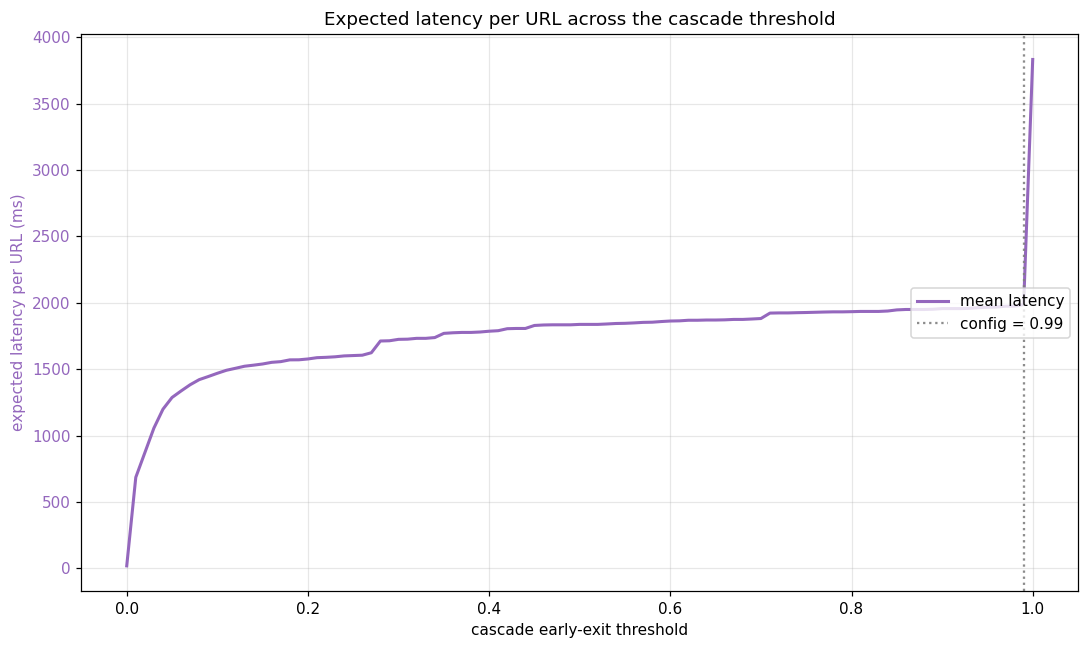

In [21]:
# Expected latency across the threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tradeoff["threshold"], tradeoff["mean_latency_ms"], color="tab:purple", lw=2, label="mean latency")
ax.set_xlabel("cascade early-exit threshold")
ax.set_ylabel("expected latency per URL (ms)", color="tab:purple")
ax.tick_params(axis="y", labelcolor="tab:purple"); ax.grid(alpha=0.3)
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9, label=f"config = {CURRENT_THRESHOLD:.2f}")
ax.legend(loc="center right")
ax.set_title("Expected latency per URL across the cascade threshold")
plt.tight_layout(); plt.show()

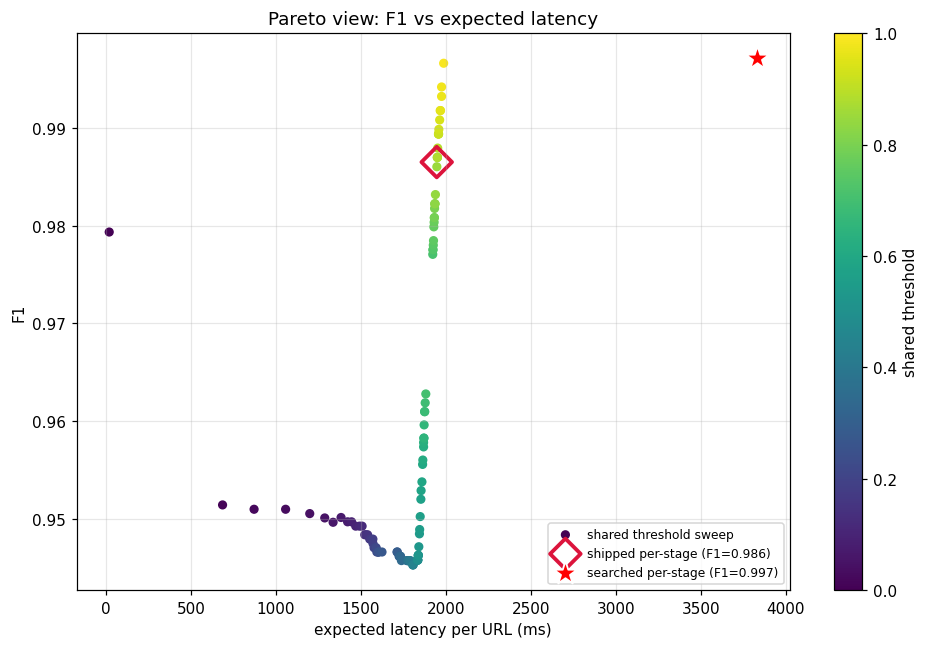

best shared-threshold F1 = 0.9971 (t=1.00)
shipped per-stage F1     = 0.9865  @ 1946.4 ms
searched per-stage F1    = 0.9971  @ 3833.1 ms


In [22]:
# Pareto view: F1 vs expected latency. Shared-threshold sweep (points colored by threshold),
# plus the two per-stage operating points.
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(tradeoff["mean_latency_ms"], tradeoff["f1"], c=tradeoff["threshold"],
                cmap="viridis", s=25, label="shared threshold sweep")
plt.colorbar(sc, label="shared threshold")
ax.scatter([CFG_LAT], [CFG_F1], s=200, marker="D", facecolor="none", edgecolor="crimson",
           lw=2.5, label=f"shipped per-stage (F1={CFG_F1:.3f})")
ax.scatter([BEST_LAT], [BEST_F1], s=260, marker="*", color="red", edgecolor="white",
           lw=1.2, label=f"searched per-stage (F1={BEST_F1:.3f})")
ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1")
ax.set_title("Pareto view: F1 vs expected latency")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

best_shared_f1 = float(best_shared["f1"])
print(f"best shared-threshold F1 = {best_shared_f1:.4f} (t={best_shared['threshold']:.2f})")
print(f"shipped per-stage F1     = {CFG_F1:.4f}  @ {CFG_LAT:.1f} ms")
print(f"searched per-stage F1    = {BEST_F1:.4f}  @ {BEST_LAT:.1f} ms")


In [23]:
tradeoff.to_csv("eval_results/latency_f1_tradeoff.csv", index=False)
print(f"saved {len(tradeoff)} rows -> eval_results/latency_f1_tradeoff.csv")

saved 101 rows -> eval_results/latency_f1_tradeoff.csv


## Full-pass (no early-exit) vs the cascade

Evaluates a system that **runs every stage for every URL and decides from the aggregate**
(no threshold early-exit) -- for each aggregation mode -- alongside single-stage-only
baselines and the cascade operating points, all on the same TEST split. Full-pass is the
ensemble's accuracy when latency is ignored (every URL pays the full stage cost); the
comparison shows exactly what the cascade's early-exit trades away.


In [24]:
# === Full-pass (run every stage, no early-exit) vs the cascade, on TEST ===
import statistics as _stats

def _agg_decode(prob_list, mode):
    ps = [p for _, p in prob_list]
    agg = {"max": max(ps), "median": _stats.median(ps)}.get(mode, _stats.fmean(ps))
    return 1 if agg >= FALLBACK_DECISION_BOUNDARY else 0

FULL_LAT = mean_latency_for(2.0)          # 2.0 > any prob => no early-exit => every stage runs

def _row(system, preds, lat):
    m = _metrics_row(preds)
    return {"system": system, "precision": m["precision"], "recall": m["recall"],
            "f1": m["f1"], "accuracy": m["accuracy"], "pred_phish": m["pred_phish"],
            "mean_latency_ms": lat}

rows = []
for mode in ["mean", "max", "median"]:
    preds = np.asarray([_agg_decode(L, mode) for L in test_probs])
    rows.append(_row(f"full-pass + {mode}", preds, FULL_LAT))

for s in STAGES:                           # single-stage-only reference (P>=0.5; missing => benign)
    preds = np.asarray([1 if any(sid == s and p >= 0.5 for sid, p in L) else 0 for L in test_probs])
    rows.append(_row(f"{s}-only (P>=0.5)", preds, LAT_MS.get(s, float("nan"))))

rows.append(_row("cascade: shipped per-stage", preds_cfg, CFG_LAT))
rows.append(_row("cascade: searched per-stage", predict_at(test_probs, best_thr), BEST_LAT))
rows.append({"system": f"cascade: best shared t={best_shared['threshold']:.2f}",
             "precision": best_shared["precision"], "recall": best_shared["recall"],
             "f1": best_shared["f1"], "accuracy": best_shared["accuracy"],
             "pred_phish": int(best_shared["pred_phish"]),
             "mean_latency_ms": mean_latency_for(float(best_shared["threshold"]))})

fullpass = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
fullpass.to_csv("eval_results/pipeline_fullpass_vs_cascade.csv", index=False)
print("Full-pass (all stages, no early-exit) vs cascade -- TEST (sorted by F1):")
print(fullpass.round(4).to_string(index=False))


Full-pass (all stages, no early-exit) vs cascade -- TEST (sorted by F1):
                     system  precision  recall     f1  accuracy  pred_phish  mean_latency_ms
           full-pass + mean     0.9961  0.9990 0.9976    0.9976        1025        3834.4621
cascade: searched per-stage     0.9942  1.0000 0.9971    0.9972        1028        3833.1422
cascade: best shared t=1.00     0.9951  0.9990 0.9971    0.9972        1026        3833.1422
         full-pass + median     0.9951  0.9971 0.9961    0.9962        1024        3834.4621
       domain-only (P>=0.5)     0.9817  1.0000 0.9908    0.9910        1041        2795.5200
 cascade: shipped per-stage     0.9733  1.0000 0.9865    0.9868        1050        1946.3534
          url-only (P>=0.5)     0.9622  0.9971 0.9793    0.9797        1059          19.0100
      content-only (P>=0.5)     0.9423  0.9912 0.9661    0.9665        1075        1041.5700
            full-pass + max     0.8981  1.0000 0.9463    0.9452        1138        3834.46

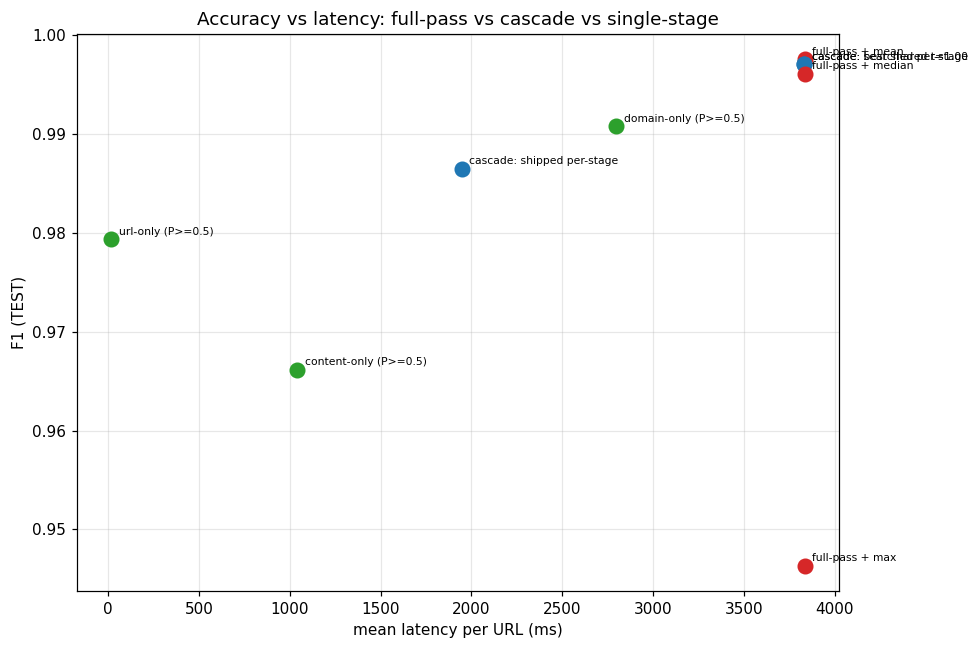

In [25]:
# Accuracy vs latency for every system (full-pass = red, cascade = blue, single-stage = green)
fig, ax = plt.subplots(figsize=(9, 6))
for _, r in fullpass.iterrows():
    if "full-pass" in r["system"]:
        c = "tab:red"
    elif "cascade" in r["system"]:
        c = "tab:blue"
    else:
        c = "tab:green"
    ax.scatter(r["mean_latency_ms"], r["f1"], s=90, color=c, zorder=3)
    ax.annotate(r["system"], (r["mean_latency_ms"], r["f1"]), fontsize=7,
                xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("mean latency per URL (ms)"); ax.set_ylabel("F1 (TEST)")
ax.set_title("Accuracy vs latency: full-pass vs cascade vs single-stage")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
